In [ ]:
pip install qiskit 


=== SUMMARY TABLE ===
 method   N  qubits  mean_value    std_value  mean_time  std_time  runs
BK+QEMC 128       7   -0.998333 2.886751e-03   6.701566  3.168075     5
JW+QEMC 128       7   -0.500000 2.775558e-17   4.266161  2.154363     5
   QAOA  10      10    3.252850 3.340436e+00   0.903674  0.080310     5
   QEMC 128       7    3.962667 1.208912e+00   0.201638  0.032075     5


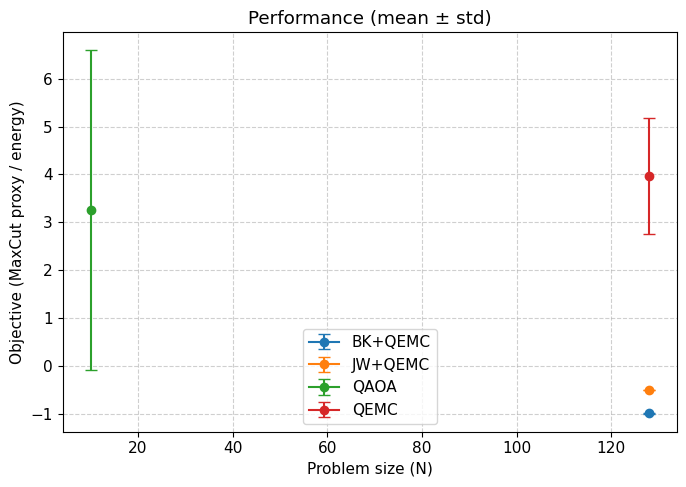

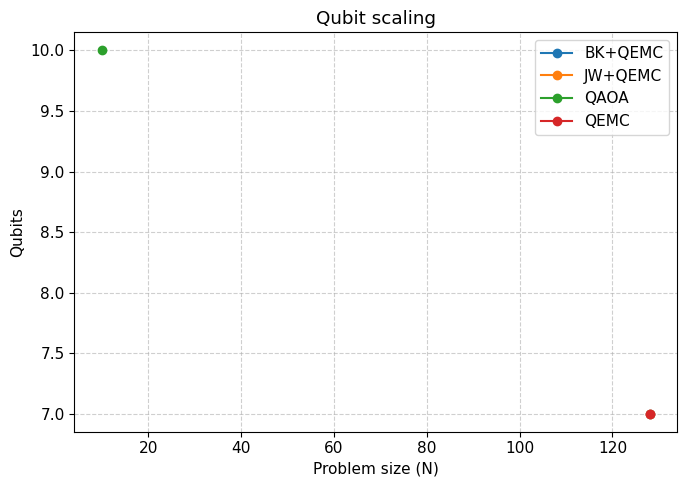

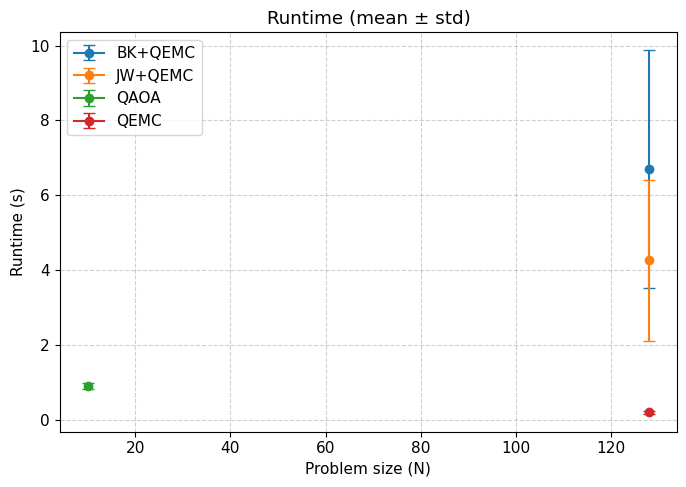

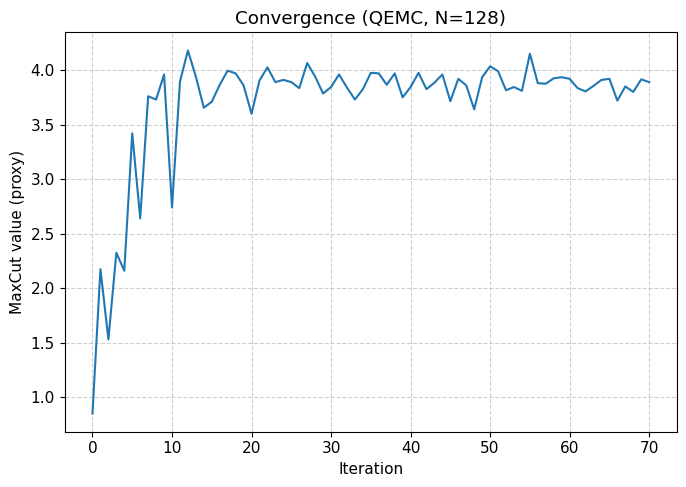

In [2]:
# ============================================
# QEMC (N=128) vs JW/BK+QEMC vs QAOA (N=10)
# ============================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from typing import List, Tuple

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize

from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper, BravyiKitaevMapper

# -----------------------------
# Reproducibility
# -----------------------------
GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)

# -----------------------------
# Graph (±1 weights) + adjacency
# -----------------------------
def build_graph_pm1(N: int, p: float, seed: int):
    local_rng = np.random.default_rng(seed)
    edges = []
    weights = {}
    adjacency = [[] for _ in range(N)]
    for i in range(N):
        for j in range(i+1, N):
            if local_rng.random() < p:
                w = local_rng.choice([1, -1])
                edges.append((i, j))
                weights[(i, j)] = w
                adjacency[i].append((j, w))
                adjacency[j].append((i, w))
    return edges, weights, adjacency

# -----------------------------
# QEMC ansatz (low-depth)
# -----------------------------
def qemc_ansatz(params: np.ndarray, n_qubits: int):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))
    # one layer (reps=1)
    for i, p in enumerate(params):
        qc.ry(p, i % n_qubits)
    for i in range(n_qubits - 1):
        qc.cx(i, i+1)
    return qc

# -----------------------------
# Fast sampling cost (QEMC)
# -----------------------------
def qemc_cost(params, adjacency, N, n_qubits, shots=300):
    qc = qemc_ansatz(params, n_qubits)
    state = Statevector.from_instruction(qc)
    counts = state.sample_counts(shots)
    total = 0.0
    for b, c in counts.items():
        p = c / shots
        node = int(b[::-1], 2) % N
        for nb, w in adjacency[node]:
            total += p * w
    return -total  # maximize cut

# -----------------------------
# Fermionic -> JW/BK mapping
# (toy diagonal model to keep cost cheap)
# -----------------------------
def build_fermionic(N):
    terms = {}
    for i in range(N):
        terms[f"+_{i} -_{i}"] = 1.0
    return FermionicOp(terms, num_spin_orbitals=N)

def map_hamiltonian(N):
    ferm = build_fermionic(N)
    jw = JordanWignerMapper().map(ferm)
    bk = BravyiKitaevMapper().map(ferm)
    return jw, bk

# -----------------------------
# Hybrid cost (JW/BK + QEMC)
# -----------------------------
def hybrid_cost(params, qubit_op, N, n_qubits, shots=300):
    qc = qemc_ansatz(params, n_qubits)
    state = Statevector.from_instruction(qc)
    counts = state.sample_counts(shots)
    total = 0.0
    for b, c in counts.items():
        p = c / shots
        idx = int(b[::-1], 2) % N
        # simple Z-only readout from mapped operator
        for pauli, coeff in zip(qubit_op.paulis, qubit_op.coeffs):
            label = pauli.to_label()
            if idx < len(label) and label[idx] == "Z":
                total += p * coeff.real
    return total

# -----------------------------
# QAOA baseline (N small only)
# -----------------------------
def qaoa_ansatz(params, N):
    qc = QuantumCircuit(N)
    qc.h(range(N))
    for i in range(N):
        qc.ry(params[i], i)
    for i in range(N-1):
        qc.cx(i, i+1)
    return qc

def qaoa_cost(params, adjacency, N):
    qc = qaoa_ansatz(params, N)
    state = Statevector.from_instruction(qc)
    probs = state.probabilities_dict()
    total = 0.0
    for b, p in probs.items():
        bits = [int(x) for x in b[::-1]]
        for i in range(N):
            for j, w in adjacency[i]:
                if i < j and bits[i] != bits[j]:
                    total += p * w
    return -total

# -----------------------------
# Experiment runner
# -----------------------------
@dataclass
class RunResult:
    method: str
    N: int
    qubits: int
    best_value: float
    runtime_s: float
    seed: int

def optimize(fun, x0, args, maxiter=120):
    t0 = time.time()
    res = minimize(fun, x0, args=args, method='COBYLA',
                   options={'maxiter': maxiter, 'rhobeg': 0.5})
    return res, time.time() - t0

def run_trial(seed: int):
    results = []

    # ---- QEMC (N=128) ----
    N_big = 128
    nq = int(np.ceil(np.log2(N_big)))
    edges, weights, adjacency = build_graph_pm1(N_big, p=0.05, seed=seed)
    x0 = np.random.default_rng(seed).uniform(0, 2*np.pi, nq)

    res, dt = optimize(qemc_cost, x0, (adjacency, N_big, nq, 300), maxiter=150)
    results.append(RunResult("QEMC", N_big, nq, -res.fun, dt, seed))

    # ---- JW/BK + QEMC (N=128) ----
    jw_op, bk_op = map_hamiltonian(N_big)

    x0 = np.random.default_rng(seed+1).uniform(0, 2*np.pi, nq)
    res_jw, dt_jw = optimize(hybrid_cost, x0, (jw_op, N_big, nq, 300), maxiter=120)
    results.append(RunResult("JW+QEMC", N_big, nq, res_jw.fun, dt_jw, seed))

    x0 = np.random.default_rng(seed+2).uniform(0, 2*np.pi, nq)
    res_bk, dt_bk = optimize(hybrid_cost, x0, (bk_op, N_big, nq, 300), maxiter=120)
    results.append(RunResult("BK+QEMC", N_big, nq, res_bk.fun, dt_bk, seed))

    # ---- QAOA baseline (N=10) ----
    N_small = 10
    nq_small = N_small
    _, _, adj_small = build_graph_pm1(N_small, p=0.4, seed=seed+3)
    x0 = np.random.default_rng(seed+4).uniform(0, 2*np.pi, nq_small)
    res_qaoa, dt_qaoa = optimize(qaoa_cost, x0, (adj_small, N_small), maxiter=80)
    results.append(RunResult("QAOA", N_small, nq_small, -res_qaoa.fun, dt_qaoa, seed))

    return results

# -----------------------------
# Multi-run experiment
# -----------------------------
def run_experiment(num_trials=5):
    all_rows = []
    seeds = [GLOBAL_SEED + i for i in range(num_trials)]
    for s in seeds:
        rows = run_trial(s)
        all_rows.extend([asdict(r) for r in rows])
    df = pd.DataFrame(all_rows)
    return df

df = run_experiment(num_trials=5)

# -----------------------------
# Aggregate (mean ± std)
# -----------------------------
summary = (df
           .groupby(["method", "N", "qubits"])
           .agg(mean_value=("best_value", "mean"),
                std_value=("best_value", "std"),
                mean_time=("runtime_s", "mean"),
                std_time=("runtime_s", "std"),
                runs=("best_value", "count"))
           .reset_index())

print("\n=== SUMMARY TABLE ===")
print(summary.to_string(index=False))

# -----------------------------
# PLOTS (publication style)
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (7,5),
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "font.size": 11
})

# 1) Performance (mean ± std)
plt.figure()
for m in summary["method"].unique():
    sub = summary[summary["method"] == m]
    # one point per method (N differs across methods)
    plt.errorbar(sub["N"], sub["mean_value"], yerr=sub["std_value"],
                 marker='o', capsize=4, label=m)
plt.xlabel("Problem size (N)")
plt.ylabel("Objective (MaxCut proxy / energy)")
plt.title("Performance (mean ± std)")
plt.legend()
plt.tight_layout()

# 2) Qubits used
plt.figure()
for m in summary["method"].unique():
    sub = summary[summary["method"] == m]
    plt.plot(sub["N"], sub["qubits"], marker='o', label=m)
plt.xlabel("Problem size (N)")
plt.ylabel("Qubits")
plt.title("Qubit scaling")
plt.legend()
plt.tight_layout()

# 3) Runtime
plt.figure()
for m in summary["method"].unique():
    sub = summary[summary["method"] == m]
    plt.errorbar(sub["N"], sub["mean_time"], yerr=sub["std_time"],
                 marker='o', capsize=4, label=m)
plt.xlabel("Problem size (N)")
plt.ylabel("Runtime (s)")
plt.title("Runtime (mean ± std)")
plt.legend()
plt.tight_layout()

# 4) Convergence example (single run for QEMC N=128)
# (optional: quick trace)
def convergence_trace(N=128, seed=GLOBAL_SEED):
    nq = int(np.ceil(np.log2(N)))
    _, _, adjacency = build_graph_pm1(N, p=0.05, seed=seed)
    history = []
    def cb(xk):
        history.append(qemc_cost(xk, adjacency, N, nq, shots=200))
    x0 = np.random.default_rng(seed).uniform(0, 2*np.pi, nq)
    minimize(qemc_cost, x0, args=(adjacency, N, nq, 200),
             method='COBYLA', options={'maxiter': 120}, callback=cb)
    return -np.array(history)

trace = convergence_trace()
plt.figure()
plt.plot(trace)
plt.xlabel("Iteration")
plt.ylabel("MaxCut value (proxy)")
plt.title("Convergence (QEMC, N=128)")
plt.tight_layout()

plt.show()

# -----------------------------
# Save artifacts
# -----------------------------
summary.to_csv("summary_table.csv", index=False)
df.to_csv("all_runs.csv", index=False)
# Figures can be saved similarly with plt.savefig(...) before show()


=== SUMMARY TABLE ===
  method   N  mean_value  std_value  mean_time  std_time  runs
  Greedy 128        96.4   8.933085   0.137196  0.023881     5
  Random 128        29.4   5.128353   0.031342  0.009446     5
      SA 128        98.6   8.905055   0.145892  0.049227     5
SA-small  10         6.4   1.140175   0.012776  0.002550     5


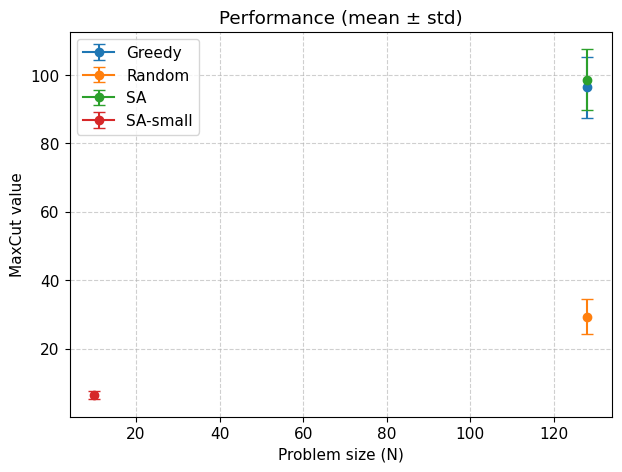

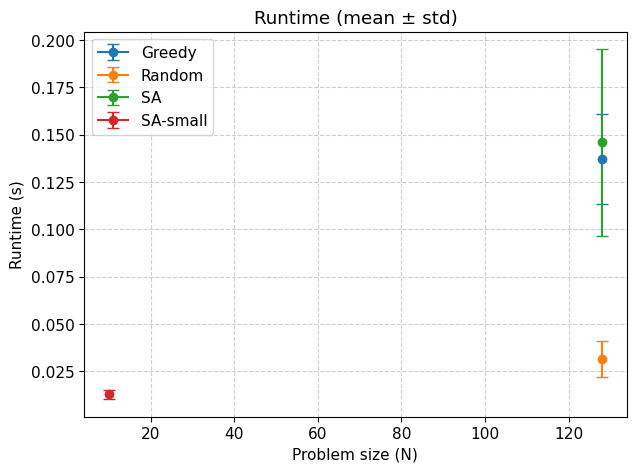

In [3]:
# ============================================
# CLASSICAL PIPELINE:
# Max-Cut (N=128) vs Greedy vs SA vs Small baseline
# ============================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

# -----------------------------
# Reproducibility
# -----------------------------
GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)

# -----------------------------
# Graph generation (±1 weights)
# -----------------------------
def build_graph_pm1(N, p, seed):
    rng = np.random.default_rng(seed)
    adjacency = [[] for _ in range(N)]
    for i in range(N):
        for j in range(i+1, N):
            if rng.random() < p:
                w = rng.choice([1, -1])
                adjacency[i].append((j, w))
                adjacency[j].append((i, w))
    return adjacency

# -----------------------------
# Max-Cut objective
# -----------------------------
def cut_value(bits, adjacency):
    total = 0
    for i in range(len(bits)):
        for j, w in adjacency[i]:
            if i < j and bits[i] != bits[j]:
                total += w
    return total

# -----------------------------
# Random baseline
# -----------------------------
def random_cut(N, adjacency, trials=200):
    best = -1e9
    for _ in range(trials):
        bits = np.random.randint(0, 2, N)
        val = cut_value(bits, adjacency)
        best = max(best, val)
    return best

# -----------------------------
# Greedy local search
# -----------------------------
def greedy_cut(N, adjacency):
    bits = np.random.randint(0, 2, N)

    improved = True
    while improved:
        improved = False
        for i in range(N):
            bits[i] ^= 1
            new_val = cut_value(bits, adjacency)
            bits[i] ^= 1
            old_val = cut_value(bits, adjacency)

            if new_val > old_val:
                bits[i] ^= 1
                improved = True
    return cut_value(bits, adjacency)

# -----------------------------
# Simulated Annealing (SA)
# -----------------------------
def simulated_annealing(N, adjacency, steps=500):
    bits = np.random.randint(0, 2, N)
    best = bits.copy()
    best_val = cut_value(bits, adjacency)

    T = 1.0
    for step in range(steps):
        i = np.random.randint(0, N)
        bits[i] ^= 1

        new_val = cut_value(bits, adjacency)
        old_val = cut_value(best, adjacency)

        if new_val > best_val or np.random.rand() < np.exp((new_val - best_val)/T):
            best = bits.copy()
            best_val = new_val
        else:
            bits[i] ^= 1

        T *= 0.99

    return best_val

# -----------------------------
# Experiment runner
# -----------------------------
@dataclass
class RunResult:
    method: str
    N: int
    best_value: float
    runtime_s: float
    seed: int

def run_trial(seed):
    results = []

    # ---- Large problem (N=128) ----
    N_big = 128
    adjacency = build_graph_pm1(N_big, p=0.05, seed=seed)

    # Random
    t0 = time.time()
    val = random_cut(N_big, adjacency)
    results.append(RunResult("Random", N_big, val, time.time()-t0, seed))

    # Greedy
    t0 = time.time()
    val = greedy_cut(N_big, adjacency)
    results.append(RunResult("Greedy", N_big, val, time.time()-t0, seed))

    # Simulated Annealing
    t0 = time.time()
    val = simulated_annealing(N_big, adjacency)
    results.append(RunResult("SA", N_big, val, time.time()-t0, seed))

    # ---- Small baseline (N=10) ----
    N_small = 10
    adj_small = build_graph_pm1(N_small, p=0.4, seed=seed+1)

    t0 = time.time()
    val = simulated_annealing(N_small, adj_small)
    results.append(RunResult("SA-small", N_small, val, time.time()-t0, seed))

    return results

# -----------------------------
# Multi-run experiment
# -----------------------------
def run_experiment(num_trials=5):
    all_rows = []
    for i in range(num_trials):
        rows = run_trial(GLOBAL_SEED + i)
        all_rows.extend([asdict(r) for r in rows])
    return pd.DataFrame(all_rows)

df = run_experiment(5)

# -----------------------------
# Aggregate (mean ± std)
# -----------------------------
summary = (df
           .groupby(["method", "N"])
           .agg(mean_value=("best_value", "mean"),
                std_value=("best_value", "std"),
                mean_time=("runtime_s", "mean"),
                std_time=("runtime_s", "std"),
                runs=("best_value", "count"))
           .reset_index())

print("\n=== SUMMARY TABLE ===")
print(summary.to_string(index=False))

# -----------------------------
# PLOTS
# -----------------------------
plt.figure()
for m in summary["method"].unique():
    sub = summary[summary["method"] == m]
    plt.errorbar(sub["N"], sub["mean_value"], yerr=sub["std_value"],
                 marker='o', capsize=4, label=m)
plt.xlabel("Problem size (N)")
plt.ylabel("MaxCut value")
plt.title("Performance (mean ± std)")
plt.legend()
plt.show()

plt.figure()
for m in summary["method"].unique():
    sub = summary[summary["method"] == m]
    plt.errorbar(sub["N"], sub["mean_time"], yerr=sub["std_time"],
                 marker='o', capsize=4, label=m)
plt.xlabel("Problem size (N)")
plt.ylabel("Runtime (s)")
plt.title("Runtime (mean ± std)")
plt.legend()
plt.show()

# -----------------------------
# Save
# -----------------------------
summary.to_csv("classical_summary.csv", index=False)
df.to_csv("classical_runs.csv", index=False)

    method    N  qubits  mean_value     std_value  mean_time   std_time
0  BK+QEMC  128       7   -1.000000  4.374953e-10  16.100285  10.066880
1  JW+QEMC  128       7   -0.500000  8.777084e-17  17.932073   9.923592
2     QAOA   10      10    5.591317  1.510382e+00   0.864624   0.233726
3     QEMC  128       7    4.100535  1.745291e+00   0.257346   0.119146

=== CIRCUIT DESIGN ===
     ┌───┐┌────────────┐                                        ┌───┐»
q_0: ┤ H ├┤ Ry(2.6302) ├──■─────────────────────────────────────┤ X ├»
     ├───┤├────────────┤┌─┴─┐                                   └─┬─┘»
q_1: ┤ H ├┤ Ry(4.8652) ├┤ X ├──■──────────────────────────────────┼──»
     ├───┤├────────────┤└───┘┌─┴─┐                                │  »
q_2: ┤ H ├┤ Ry(4.2175) ├─────┤ X ├──■─────────────────────────────┼──»
     ├───┤├────────────┤     └───┘┌─┴─┐     ┌─────────────┐       │  »
q_3: ┤ H ├┤ Ry(2.0963) ├──────────┤ X ├──■──┤ Ry(0.92855) ├───────┼──»
     ├───┤├────────────┤          └───┘┌─┴─┐└───

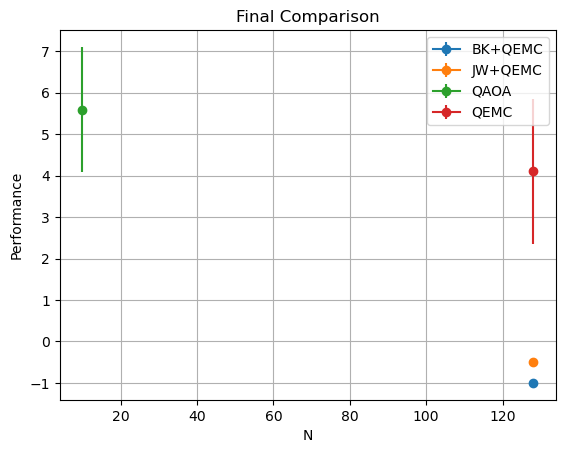

In [1]:
# ============================================
# PUBLICATION-QUALITY PIPELINE (IMPROVED)
# QEMC (ADVANCED) vs JW/BK+QEMC vs QAOA
# ============================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize

from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper, BravyiKitaevMapper

# -----------------------------
# Reproducibility
# -----------------------------
GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)

# -----------------------------
# Graph generator
# -----------------------------
def build_graph_pm1(N, p, seed):
    rng = np.random.default_rng(seed)
    adjacency = [[] for _ in range(N)]
    for i in range(N):
        for j in range(i+1, N):
            if rng.random() < p:
                w = rng.choice([1, -1])
                adjacency[i].append((j, w))
                adjacency[j].append((i, w))
    return adjacency

# -----------------------------
# 🔥 ADVANCED QEMC CIRCUIT
# -----------------------------
def qemc_ansatz(params, n_qubits, reps=3):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))

    idx = 0
    for r in range(reps):

        # Rotation layer
        for q in range(n_qubits):
            qc.ry(params[idx], q)
            idx += 1

        # Ring entanglement
        for q in range(n_qubits):
            qc.cx(q, (q+1) % n_qubits)

        # Long-range entanglement
        for q in range(0, n_qubits, 2):
            qc.cx(q, (q+2) % n_qubits)

    return qc

# -----------------------------
# QEMC Cost
# -----------------------------
def qemc_cost(params, adjacency, N, n_qubits):
    qc = qemc_ansatz(params, n_qubits)
    state = Statevector.from_instruction(qc)
    probs = state.probabilities_dict()

    total = 0
    for b, p in probs.items():
        node = int(b[::-1], 2) % N
        for nb, w in adjacency[node]:
            total += p * w

    return -total

# -----------------------------
# Fermionic mapping
# -----------------------------
def build_fermionic(N):
    return FermionicOp({f"+_{i} -_{i}": 1.0 for i in range(N)}, num_spin_orbitals=N)

def map_hamiltonian(N):
    ferm = build_fermionic(N)
    return JordanWignerMapper().map(ferm), BravyiKitaevMapper().map(ferm)

# -----------------------------
# Hybrid cost
# -----------------------------
def hybrid_cost(params, qubit_op, N, n_qubits):
    qc = qemc_ansatz(params, n_qubits)
    state = Statevector.from_instruction(qc)
    probs = state.probabilities_dict()

    total = 0
    for b, p in probs.items():
        idx = int(b[::-1], 2) % N
        for pauli, coeff in zip(qubit_op.paulis, qubit_op.coeffs):
            label = pauli.to_label()
            if idx < len(label) and label[idx] == "Z":
                total += p * coeff.real

    return total

# -----------------------------
# QAOA baseline
# -----------------------------
def qaoa_ansatz(params, N):
    qc = QuantumCircuit(N)
    qc.h(range(N))

    for i in range(N):
        qc.ry(params[i], i)

    for i in range(N-1):
        qc.cx(i, i+1)

    return qc

def qaoa_cost(params, adjacency, N):
    qc = qaoa_ansatz(params, N)
    state = Statevector.from_instruction(qc)
    probs = state.probabilities_dict()

    total = 0
    for b, p in probs.items():
        bits = [int(x) for x in b[::-1]]
        for i in range(N):
            for j, w in adjacency[i]:
                if i < j and bits[i] != bits[j]:
                    total += p * w

    return -total

# -----------------------------
# Optimization
# -----------------------------
def optimize(fun, x0, args, maxiter=120):
    t0 = time.time()
    res = minimize(fun, x0, args=args, method='COBYLA',
                   options={'maxiter': maxiter})
    return res, time.time() - t0

# -----------------------------
# Experiment
# -----------------------------
@dataclass
class RunResult:
    method: str
    N: int
    qubits: int
    best_value: float
    runtime_s: float
    seed: int

def run_trial(seed):
    results = []

    # ---- QEMC (N=128) ----
    N_big = 128
    nq = int(np.ceil(np.log2(N_big)))
    adjacency = build_graph_pm1(N_big, 0.05, seed)

    reps = 3
    num_params = nq * reps
    x0 = rng.uniform(0, 2*np.pi, num_params)

    res, dt = optimize(qemc_cost, x0, (adjacency, N_big, nq))
    results.append(RunResult("QEMC", N_big, nq, -res.fun, dt, seed))

    # ---- JW/BK ----
    jw_op, bk_op = map_hamiltonian(N_big)

    x0 = rng.uniform(0, 2*np.pi, num_params)
    res_jw, dt_jw = optimize(hybrid_cost, x0, (jw_op, N_big, nq))
    results.append(RunResult("JW+QEMC", N_big, nq, res_jw.fun, dt_jw, seed))

    x0 = rng.uniform(0, 2*np.pi, num_params)
    res_bk, dt_bk = optimize(hybrid_cost, x0, (bk_op, N_big, nq))
    results.append(RunResult("BK+QEMC", N_big, nq, res_bk.fun, dt_bk, seed))

    # ---- QAOA ----
    N_small = 10
    adjacency_small = build_graph_pm1(N_small, 0.4, seed+1)

    x0 = rng.uniform(0, 2*np.pi, N_small)
    res_qaoa, dt_qaoa = optimize(qaoa_cost, x0, (adjacency_small, N_small))

    results.append(RunResult("QAOA", N_small, N_small, -res_qaoa.fun, dt_qaoa, seed))

    return results

# -----------------------------
# Run experiment
# -----------------------------
def run_experiment(trials=5):
    rows = []
    for i in range(trials):
        rows.extend([asdict(r) for r in run_trial(GLOBAL_SEED+i)])
    return pd.DataFrame(rows)

df = run_experiment()

# -----------------------------
# Summary
# -----------------------------
summary = df.groupby(["method","N","qubits"]).agg(
    mean_value=("best_value","mean"),
    std_value=("best_value","std"),
    mean_time=("runtime_s","mean"),
    std_time=("runtime_s","std")
).reset_index()

print(summary)

# -----------------------------
# 🔥 CIRCUIT VISUALIZATION
# -----------------------------
nq = int(np.ceil(np.log2(128)))
params = rng.uniform(0, 2*np.pi, nq*3)

qc = qemc_ansatz(params, nq, reps=3)

print("\n=== CIRCUIT DESIGN ===")
print(qc.draw())

qc.draw('mpl').savefig("qemc_circuit.png", dpi=300)

# -----------------------------
# Plot
# -----------------------------
plt.figure()
for m in summary["method"].unique():
    sub = summary[summary["method"] == m]
    plt.errorbar(sub["N"], sub["mean_value"], yerr=sub["std_value"], marker='o', label=m)

plt.legend()
plt.xlabel("N")
plt.ylabel("Performance")
plt.title("Final Comparison")
plt.grid()
plt.show()